# qid 128 — does more retention fix it?

Follow-up to `CASE_qid128_compression.ipynb`. There, whole-video compression at
**retention 0.1** left ~6 of 48 patches per frame and the agent answered *"I have not found
any scene where a woman throws a Coca-Cola can"*. The obvious question: **is 0.1 simply too
aggressive?**

This notebook turns the retention knob to **0.2 / 0.3 / 0.5** on the *same* question, the
*same* video, the *same* 2,128 decoded frames — and adds two controls that were missing:

1. a **provenance check** (nothing about this case is hardcoded — the exact prompt is printed);
2. a **reach control** — hand the model the ground-truth window at full detail and see whether
   it can answer at all.

The second one changes the conclusion of the previous notebook. Section 5.

In [1]:
import json, numpy as np, matplotlib
matplotlib.use("Agg"); import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

A   = "/local1/cfyang/hanklin/outputs/fast_agent/analysis"
S   = json.load(open(f"{A}/qid128_r30/summary.json"))
OLD = json.load(open(f"{A}/qid128/summary.json"))        # the r=0.1 run
LAD = S["r_ladder"]

print(S["question"]); [print("  ", o) for o in S["options"]]
print(f"\ngold={S['gold']}   GT evidence={S['evidence']}s   duration={S['duration']:.0f}s")
print(f"frames fed to the compressor: {S['n_frames_in']}  (identical across every retention)")

What does the woman do before throwing the Coca-Cola can into the air?
   A. She dances with people
   B. She throws her shoe away
   C. She walks barefoot
   D. She fights with a police

gold=A   GT evidence=[924.0, 945.0]s   duration=3296s
frames fed to the compressor: 2128  (identical across every retention)


## 1. Provenance — what is actually fixed, and what the model chose

Fair question to ask of a single-case study. Three things are supplied by the harness, and
they are the *same three* every LVBench question in every arm gets:

| supplied | by | question-specific? |
|---|---|---|
| 64 uniform skim frames + their timestamps | `tools.initial_frames_with_timestamps` | no |
| the two tool schemas (`# Tools` block) | `config.TOOL_SCHEMAS` | no |
| one generic strategy sentence | `config.tool_instructions` | no |

Nothing else. **The tool name, the span `(0, 3296)`, and the final answer are all generated
text**, parsed out of the model's own output by `parse_tool_call` /
`data.extract_answer`. There is no branch anywhere keyed on qid 128, and the GT evidence
window (924–945 s) never appears in the prompt.

Here is the complete prompt, verbatim:

In [2]:
print(open(f"{A}/qid128_r30/prompt.txt").read())

========================== SYSTEM + # Tools BLOCK ==========================
<|im_start|>system
# Tools

You may call one or more functions to assist with the user query.

You are provided with function signatures within <tools></tools> XML tags:
<tools>
{"type": "function", "function": {"name": "crop_video", "description": "Zoom in on a specific time span and view it at FULL detail (1 frame per second, up to 128 frames). Use a TIGHT span (<=120 seconds) to read fine details, on-screen text, or faces.", "parameters": {"type": "object", "properties": {"start_time": {"type": "number", "description": "Start time in seconds."}, "end_time": {"type": "number", "description": "End time in seconds, must be greater than start_time."}}, "required": ["start_time", "end_time"]}}}
{"type": "function", "function": {"name": "compress_video", "description": "View a COMPRESSED overview of a LONG span (up to the whole video): many more frames at the same token cost as crop_video, trading per-frame detai

Note what the skim *does* contain: frame times `... 850, 901, 953, 1004 ...`. The evidence
window 924–945 s falls in the **gap between frame 18 (901 s) and frame 19 (953 s)** — the
uniform skim steps straight over it. That is the reach problem in one line.

And the model's own words, unedited, at both retentions:

In [3]:
for tag, p in [("retention 0.1", f"{A}/qid128/agent_run/traj/128.json"),
               ("retention 0.3", f"{A}/qid128_r30/agent_run/traj/128.json")]:
    d = json.load(open(p))
    print("=" * 78); print(f"{tag}   pred={d['pred']}  gold={d['gold']}  correct={d['correct']}")
    print("=" * 78)
    for r in d["rounds"]:
        print(f"--- round {r['round']}   context = {r['context_tokens']:,} tokens ---")
        print(r["thinking"].strip())
        if r["tool_result"]:
            tr = r["tool_result"]
            print(f"  [tool ran] {tr['tool']} {tr['span']} -> {tr['n_frames']} frames, "
                  f"{tr.get('kept_tokens')} tokens kept of {tr.get('base_tokens')} "
                  f"(retention {tr.get('retention')})")
        print()

retention 0.1   pred=None  gold=A  correct=False
--- round 0   context = 4,176 tokens ---
I need to find the moment when the woman throws a Coca-Cola can into the air and identify what she did immediately before that action. I'll start by using `compress_video` to scan the entire video to locate this specific scene.

<tool_call>
{"name": "compress_video", "arguments": {"start_time": 0, "end_time": 3296}}
</tool_call>
  [tool ran] compress_video [0.0, 3296.0] -> 2128 frames, 5719 tokens kept of 51072 (retention 0.1)

--- round 1   context = 21,361 tokens ---
I have reviewed the entire video using `compress_video` and have not found any scene where a woman throws a Coca-Cola can into the air. The video contains various animated scenes, including cityscapes, abstract art, and characters in different settings, but there is no depiction of a woman performing this specific action. Therefore, I cannot answer the question as the event described does not occur in the video.

<answer>None of the

**Round 0 is byte-identical at both retentions** — the model picks `compress_video(0, 3296)`
before it has seen anything compressed, so the choice cannot be an artefact of what
compression returned. Round 1 differs only in wording; the verdict is the same.

The context token count is the receipt that the retention change actually reached the LM:
**21,361 → 31,991 tokens**, i.e. 5,714 → 16,348 visual tokens for the same 2,128 frames.

## 2. Retention 0.1 → 0.5: per-frame legibility

One decoded frame tensor, four compressions. Panels left to right:
**original · r=0.1 · r=0.2 · r=0.3 · r=0.5**. Everything the compressor discarded is black.

These frames are from *inside* the ground-truth evidence window.

**t = 927s** — kept tokens — r=0.1: 6/48  ·  r=0.2: 11/48  ·  r=0.3: 16/48  ·  r=0.5: 25/48

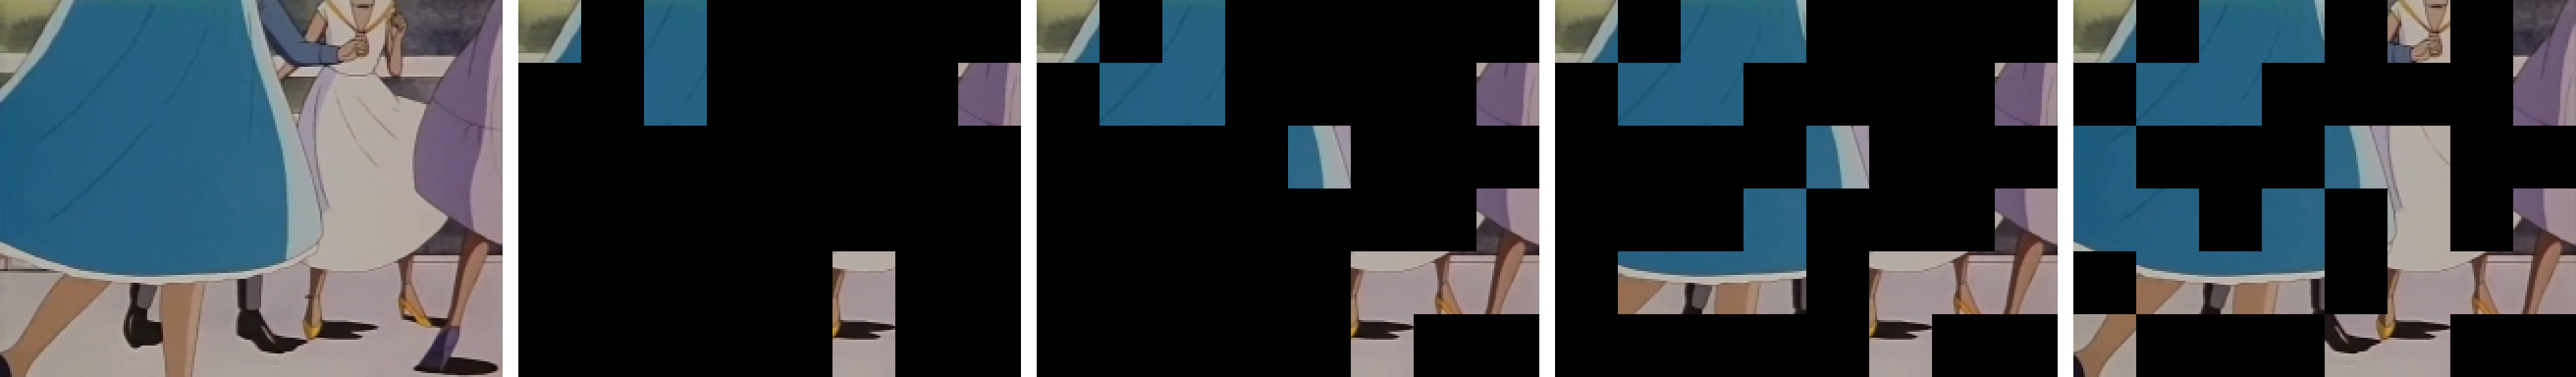

**t = 930s** — kept tokens — r=0.1: 6/48  ·  r=0.2: 12/48  ·  r=0.3: 17/48  ·  r=0.5: 26/48

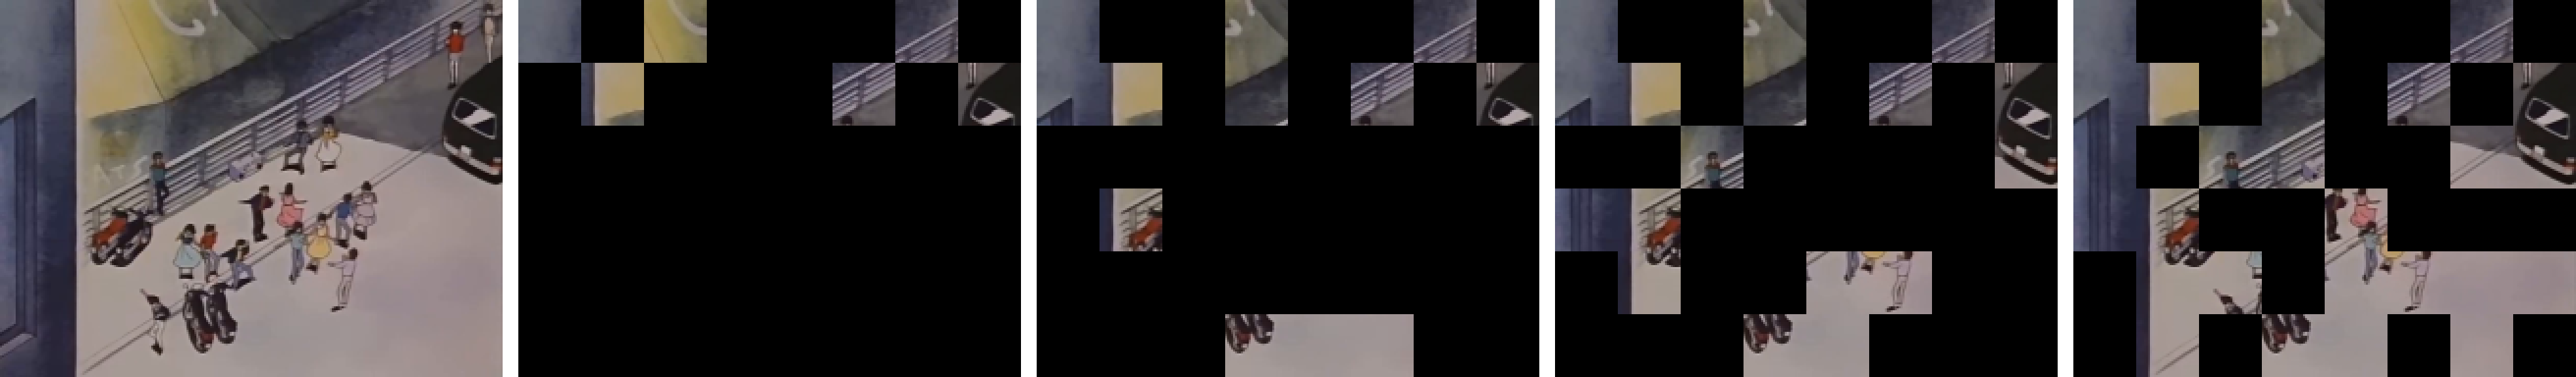

**t = 933s** — kept tokens — r=0.1: 5/48  ·  r=0.2: 9/48  ·  r=0.3: 14/48  ·  r=0.5: 23/48

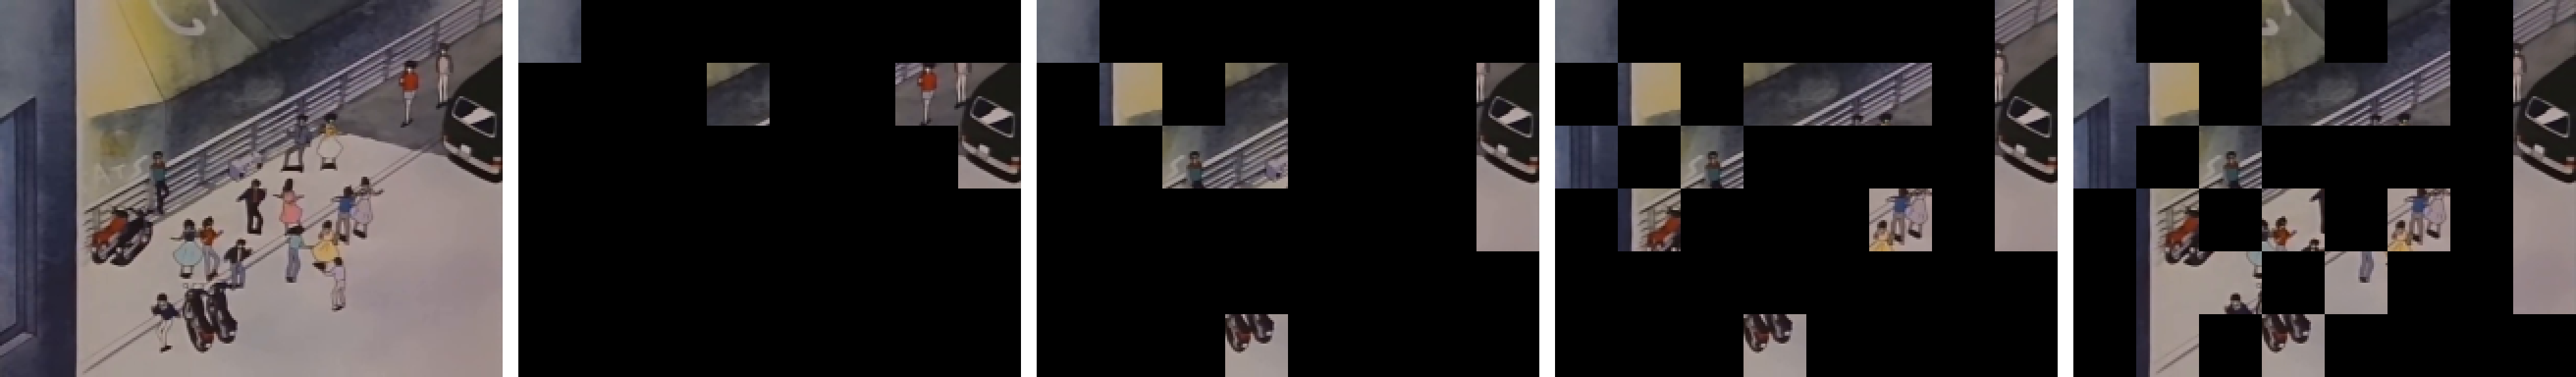

In [4]:
for r in S["renders"]:
    k = r["kept"]
    line = "  ·  ".join(f"r={a}: {k[a]}/{r['of']}" for a in [str(x) for x in LAD])
    display(Markdown(f"**t = {r['time']:.0f}s** — kept tokens — {line}"))
    display(Image(filename=r["png"]))

At **r=0.1** the frame is unreadable — a fragment of skirt and one shoe. At **r=0.3** the blue
skirt, the white skirt and the shoes resolve; you can tell people are standing close together
in motion. At **r=0.5** it is essentially the frame with holes in it.

So the user's read was right: **0.1 is too aggressive.** Per-frame legibility is genuinely
restored by turning the knob up. What that costs, and what it does *not* buy, is next.

## 3. What the extra budget buys — and what it doesn't

`crop_video`'s budget is 128 frames × 48 tokens ≈ **6.1k tokens**. That is the yardstick the
compress tool was calibrated against (`config.FIXED_RETENTION = 0.1` exists precisely to make
`compress_video` cost the same as `crop_video`).

In [5]:
rows = []
for R in LAD:
    st = S["stats"][str(R)]
    rows.append((R, st["kept"], st["kept"] / 6144, st["median_kept"], st["concentration"],
                 st["zero_groups"]))
print(f"{'retention':>10} {'kept tokens':>12} {'x crop budget':>14} "
      f"{'median kept/frame':>18} {'concentration':>14} {'empty frames':>13}")
for R, k, x, m, c, z in rows:
    print(f"{R:>10} {k:>12,} {x:>13.1f}x {m:>15.0f}/48 {c:>14.2f}x {z:>13}")

 retention  kept tokens  x crop budget  median kept/frame  concentration  empty frames
       0.1        5,714           0.9x               5/48           1.03x             0
       0.2       11,026           1.8x              10/48           0.99x             0
       0.3       16,334           2.7x              15/48           1.00x             0
       0.5       25,902           4.2x              24/48           0.99x             0


Two columns matter.

**`x crop budget`** — retention 0.3 is not a free improvement. It costs **2.7× more tokens
than `crop_video`**, which dissolves the entire premise of `compress_video`: *"many more
frames at the same token cost as crop_video"* (its own tool description). At r=0.3 you could
instead afford **340 full-detail frames** of `crop_video`. The compressed view is only worth
its price if the 1,064 shredded frames beat 340 clean ones — and at 1.0× concentration there
is no reason to think they do.

**`concentration`** — the share of surviving tokens that land inside the GT evidence window,
divided by what a uniform spread would give. It sits at **1.03 / 0.99 / 1.00 / 0.99** across the
whole ladder. Retention changes *how much* survives; it does not change *where* it survives.

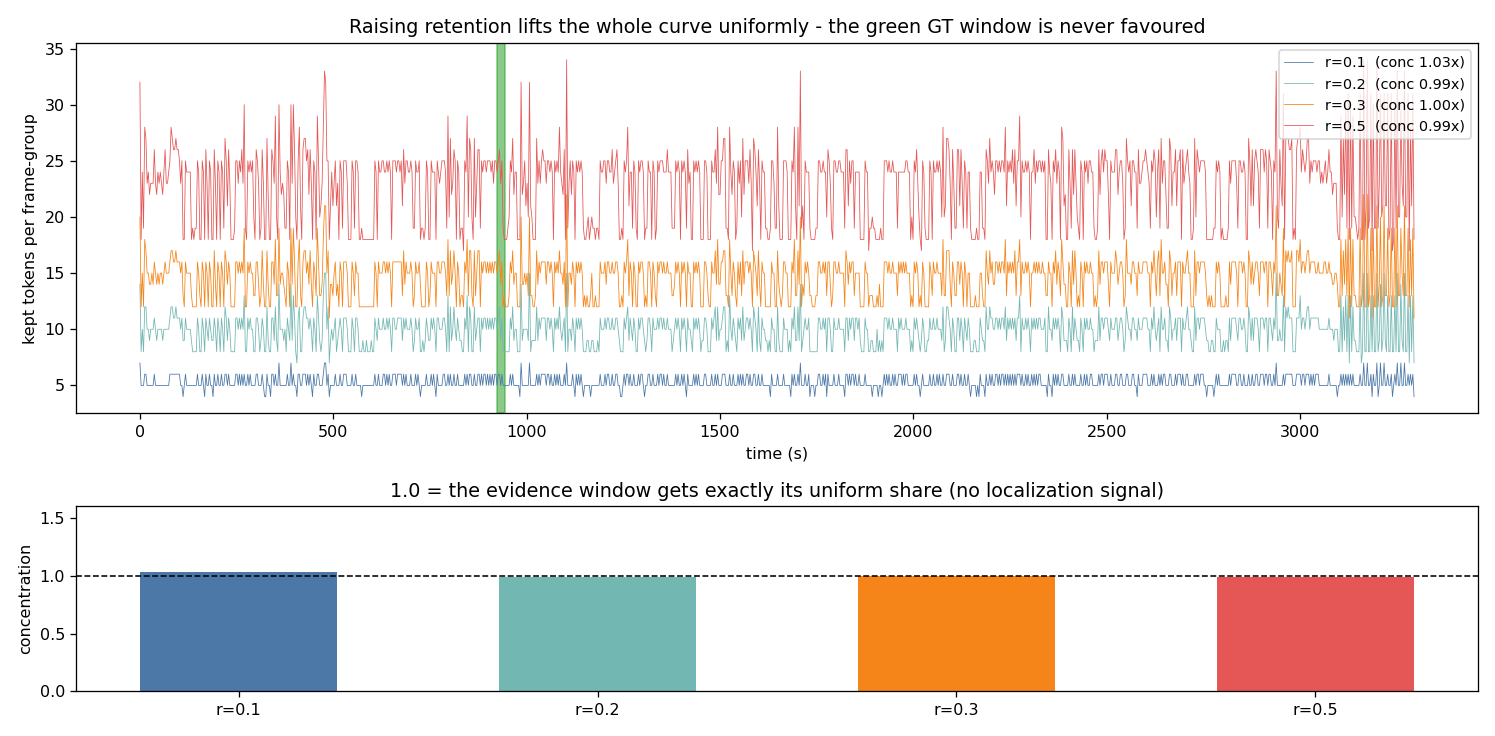

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6.4), gridspec_kw={"height_ratios": [2, 1]})
ev = S["evidence"]
cols = {0.1: "#4C78A8", 0.2: "#72B7B2", 0.3: "#F58518", 0.5: "#E45756"}
for R in LAD:
    st = S["stats"][str(R)]
    ax[0].plot(st["group_time"], st["kept_per_group"], lw=.5,
               color=cols[R], label=f"r={R}  (conc {st['concentration']:.2f}x)")
ax[0].axvspan(*ev, color="#2CA02C", alpha=.55)
ax[0].set_ylabel("kept tokens per frame-group"); ax[0].set_xlabel("time (s)")
ax[0].legend(loc="upper right", fontsize=9)
ax[0].set_title("Raising retention lifts the whole curve uniformly - the green GT window "
                "is never favoured")

x = np.arange(len(LAD))
conc = [S["stats"][str(R)]["concentration"] for R in LAD]
ax[1].bar(x, conc, color=[cols[R] for R in LAD], width=.55)
ax[1].axhline(1.0, color="k", ls="--", lw=1)
ax[1].set_xticks(x); ax[1].set_xticklabels([f"r={R}" for R in LAD])
ax[1].set_ylim(0, 1.6); ax[1].set_ylabel("concentration")
ax[1].set_title("1.0 = the evidence window gets exactly its uniform share (no localization signal)")
plt.tight_layout(); plt.savefig("/tmp/q128_ladder.png", dpi=115); plt.close()
display(Image("/tmp/q128_ladder.png"))

## 4. The agent at retention 0.3 — same refusal

Three times the tokens, legible frames, and the run is unchanged: `compress_video(0, 3296)` →
*"I have reviewed the entire video ... and have not found any scene where a woman throws a
Coca-Cola can into the air"* → `<answer>None of the above</answer>` → `pred=None`, wrong.

It never issued the `crop_video` follow-up at either retention. **Legibility was not the
binding constraint.** With 1,064 frame-groups in context and no signal pointing anywhere, the
model has no basis to nominate a window — so the second step of the chain never fires.

## 5. The control that changes the story: hand it the answer window

The previous notebook concluded *"the evidence was deleted before it reached the language
model."* That is true about what the tool did. It also implies a counterfactual — *deliver the
evidence and the model gets it right* — which I did not test. Testing it now.

First, is the evidence actually there? `crop_video(918, 951)`, full detail, 1 fps — the
33 frames the tool would return:

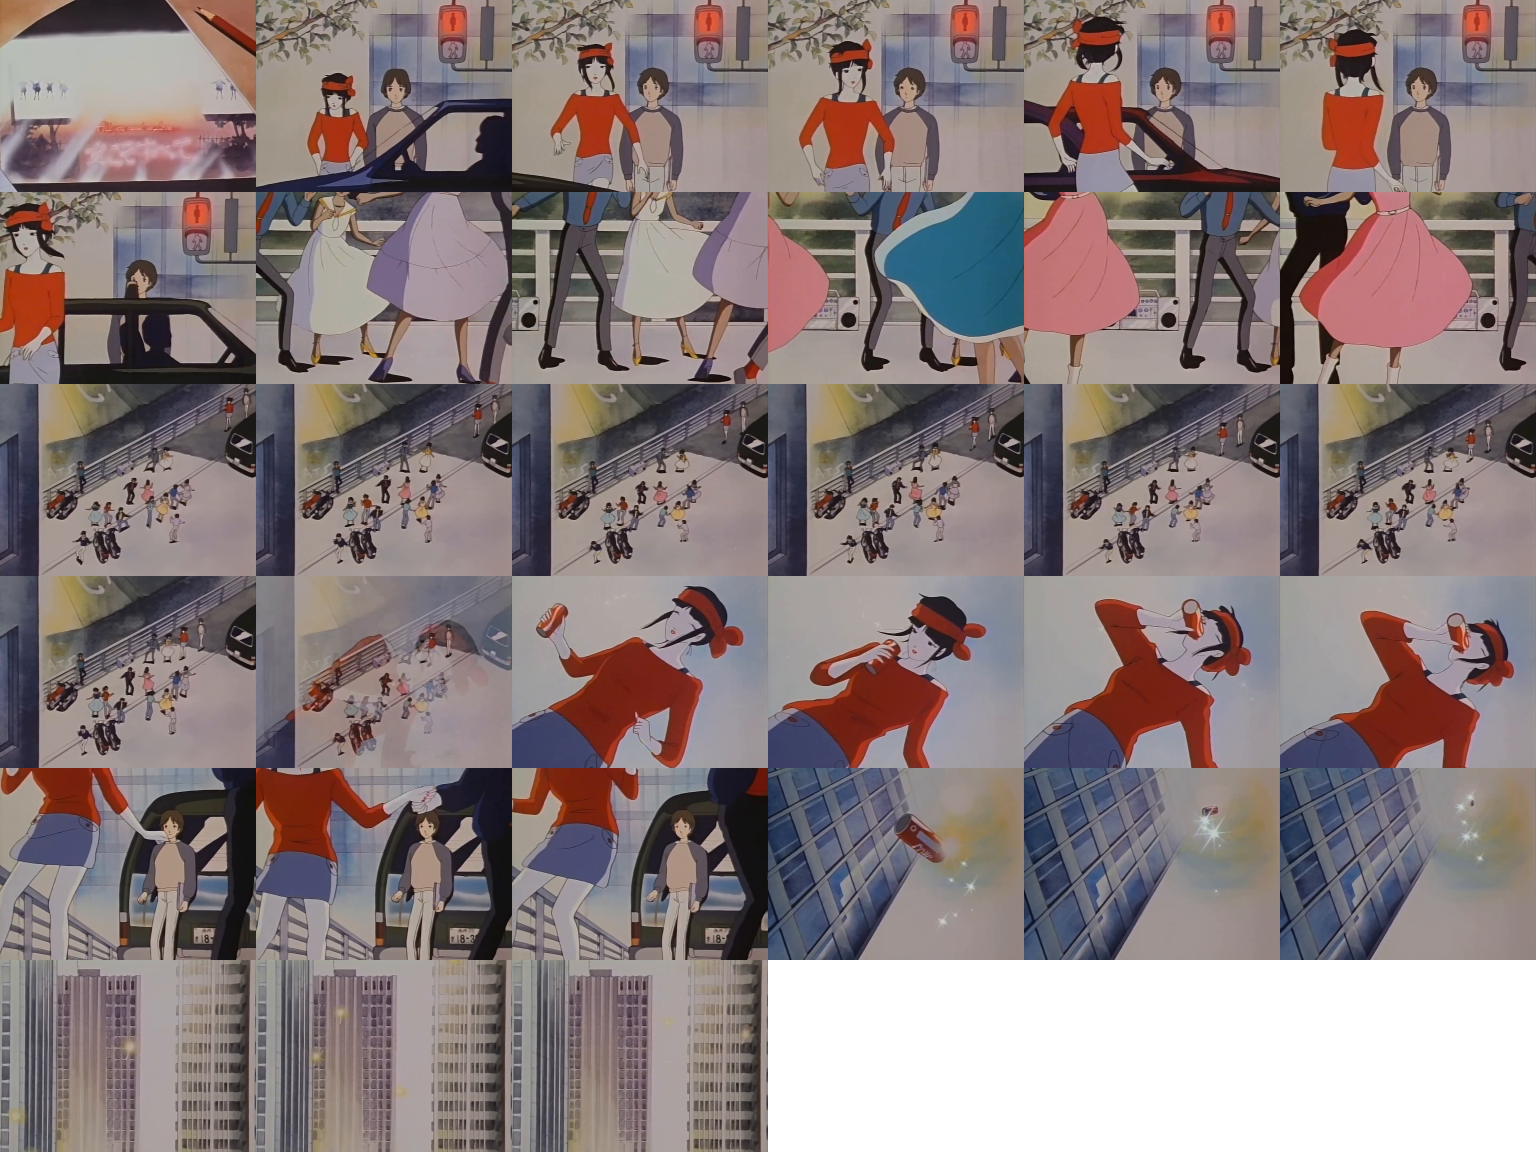

In [7]:
display(Image(filename=f"{A}/qid128_r30/gt_window_fulldetail.png"))

Reading across: a **crowd dancing**, skirts swirling (rows 1–2) → the crowd from above →
a woman in red **drinking from a red can** → **standing beside a man at a car** → the can
**thrown, spinning against a glass tower**. The gold answer *"she dances with people"* is
visibly supported. The window is sufficient.

Now feed exactly that to the model — same harness, same injection format, span supplied,
**answer not supplied**:

In [8]:
rc  = json.load(open(f"{A}/qid128_r30/reach_control.json"))
rcc = json.load(open(f"{A}/qid128_r30/reach_control_cot.json"))
print(f"crop_video(918, 951) -> {rc['n_frames']} full-detail frames\n")
print("--- direct answer turn ---")
print(rc["text"].strip()[:400])
print(f"  pred={rc['pred']}  gold={rc['gold']}  correct={rc['correct']}\n")
print("--- with the think-first instruction re-issued ---")
print(rcc["text"].strip()[:900] + " ...")
print(f"  pred={rcc['pred']}  gold={rcc['gold']}  correct={rcc['correct']}")

crop_video(918, 951) -> 33 full-detail frames

--- direct answer turn ---
<answer>B</answer>
  pred=B  gold=A  correct=False

--- with the think-first instruction re-issued ---
The woman is seen holding a Coca-Cola can and then throwing it into the air. Before this action, she is standing next to a man at a crosswalk, and they appear to be having a conversation. She does not dance with people, throw her shoe away, or fight with a police officer in the frames leading up to the throw. Therefore, the correct answer is not A, B, or D. The action of throwing the can is the main event, and the preceding action is simply standing and talking. None of the given options accurately describe what she does immediately before throwing the can. However, since the question asks what she does before throwing the can, and the only action shown before that is standing and talking, none of the options are correct. But since we must choose from the given options, and option C is not directly supported by 

**It still gets it wrong.** And the reasoning shows why — it is not a perception failure:

> *"The woman is seen holding a Coca-Cola can and then throwing it into the air. Before this
> action, she is standing next to a man at a crosswalk... She does not dance with people..."*

The model **reads the scene correctly**. It sees the can, sees the throw, sees the shot that
immediately precedes the throw — a woman standing by a car. It then rejects A because the
dancing happened ~15 seconds *earlier*, not immediately before. That is a defensible reading
of *"before"* that the benchmark does not share. Then greedy decoding collapses into
`"The correct answer is not A, B, C, or D."` repeated to the token limit.

(The `pred=D` is a scoring artefact: the 200-character tail window cuts an enumeration
mid-phrase, so `_ENUM_RE` misses it and the fallback returns the last bare letter. Wrong
either way, but the refusal is being booked as a confident D.)

Confirming against the arms already on disk — **qid 128 is wrong in every one**, including
the oracle that is handed the GT span:

In [9]:
import os
R = "/local1/cfyang/hanklin/outputs/fast_agent/runs"
print(f"{'run':<28} {'pred':>5} {'gold':>5} {'correct':>8}")
for d in sorted(os.listdir(R)):
    f = os.path.join(R, d, "results.jsonl")
    if not os.path.exists(f):
        continue
    for ln in open(f):
        try:
            j = json.loads(ln)
        except json.JSONDecodeError:
            continue
        if str(j.get("question_id")) == "128":
            print(f"{d:<28} {str(j.get('pred')):>5} {str(j.get('gold')):>5} "
                  f"{str(j.get('correct')):>8}")
            break
print(f"{'reach control (this nb)':<28} {str(rc['pred']):>5} {str(rc['gold']):>5} "
      f"{str(rc['correct']):>8}")

run                           pred  gold  correct
lvbench_baseline_full         None     A    False
lvbench_crop_full                C     A    False
lvbench_oracle_crop_cot       None     A    False
lvbench_oracle_crop_full         C     A    False
lvbench_oracle_ctrl_full         C     A    False
reach control (this nb)          B     A    False


## 6. Verdict

**On retention.** 0.1 is too aggressive — that part of the read is confirmed, and the ladder
shows exactly where legibility returns (≈0.3). But raising it does not fix the tool:

- **cost** — r=0.3 costs 2.7× `crop_video`'s budget, which contradicts the tool's whole
  selling point. Its equivalent in full-detail frames is 340 clean frames vs 1,064 shredded ones.
- **concentration stays 1.0 at every retention.** FlashVID spreads budget uniformly by
  construction; more budget is more uniform spread. The coarse step still cannot say *"look
  near here"*, so `crop_video` never fires and the chain never completes.
- **the agent's behaviour is unchanged** at 3× the tokens.

The bottleneck is *where* the tokens go, not *how many*. That is a **query-conditioning**
problem, and it is the one thing retention cannot touch — which is the argument for the
query-aware compressor rather than a bigger budget.

**On qid 128 specifically — correcting the previous notebook.** Saying the evidence was
deleted before reaching the LM is accurate about the mechanism, but the implied counterfactual
is false. Handed the GT window at full detail the model still misses, and it misses for a
*different* reason: it reads the scene correctly and disagrees about the temporal scope of
"before". So qid 128 is a clean **demonstration** of what uniform compression destroys, and it
is **not** evidence that fixing compression would flip this answer. It is in the 88.5% bucket
of oracle failures already attributed to base-model perception/reasoning, and it fails in all
five arms on disk.

The case for a query-aware coarse step still rests on the aggregate result
(`oracle_crop − oracle_ctrl = +23.0 pp`, p=3.1e-8), not on this question.

**What to run next.** The single-variable test this sets up: rerun this exact case under
`FA_COMPRESSOR=semvid` **at r=0.1** — matched budget, only the selection rule changes. The
number to watch is concentration. FlashVID sits at 1.0 across the whole ladder; if SemVID
lifts it materially, compress→crop becomes viable at the original budget and the whole
retention question is moot.

**One thing not to train away.** Under an outcome-only reward every trajectory here is
penalised, including the correct coarse-to-fine opening move in round 0. Shaping on final
answer alone selects against reaching for the coverage tool at all.